<a href="https://colab.research.google.com/github/p30692534-spec/customer-churn-prediction/blob/main/Copy_of_Customer_churn_prediction_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Step 1: Libraries import**

Load the Python libraries needed for data handling, visualization, and machine learning. These include pandas, scikit-learn, and XGBoost.

In [ ]:
import os, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, precision_recall_curve)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

**Step 2: Data load**

Read the Telco customer dataset (7,043 customers, 21 columns) into a DataFrame. Inspect its shape and first few rows to understand what each column represents.

In [ ]:
URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
if not os.path.exists("telco.csv"):
    urllib.request.urlretrieve(URL, "telco.csv")

df = pd.read_csv("telco.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Step 3: Data cleaning**

Convert TotalCharges from text to numeric, fill the 11 blank values with 0 (new customers with zero tenure), and drop the customerID column. Encode the target Churn as 1 (Yes) and 0 (No).

In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)
df = df.drop(columns=["customerID"])            # ID-ku prediction value illa
df["Churn"] = (df["Churn"] == "Yes").astype(int)  # Yes/No -> 1/0

print("Missing:", df.isna().sum().sum())
print(f"Churn rate: {df['Churn'].mean():.1%}")

Missing: 0
Churn rate: 26.5%


**Step 4: Exploratory Data Analysis (EDA)**

Visualize how churn varies across contract type, internet service, payment method, tenure, and charges. This reveals the key patterns, such as month-to-month customers churning far more than long-term ones.


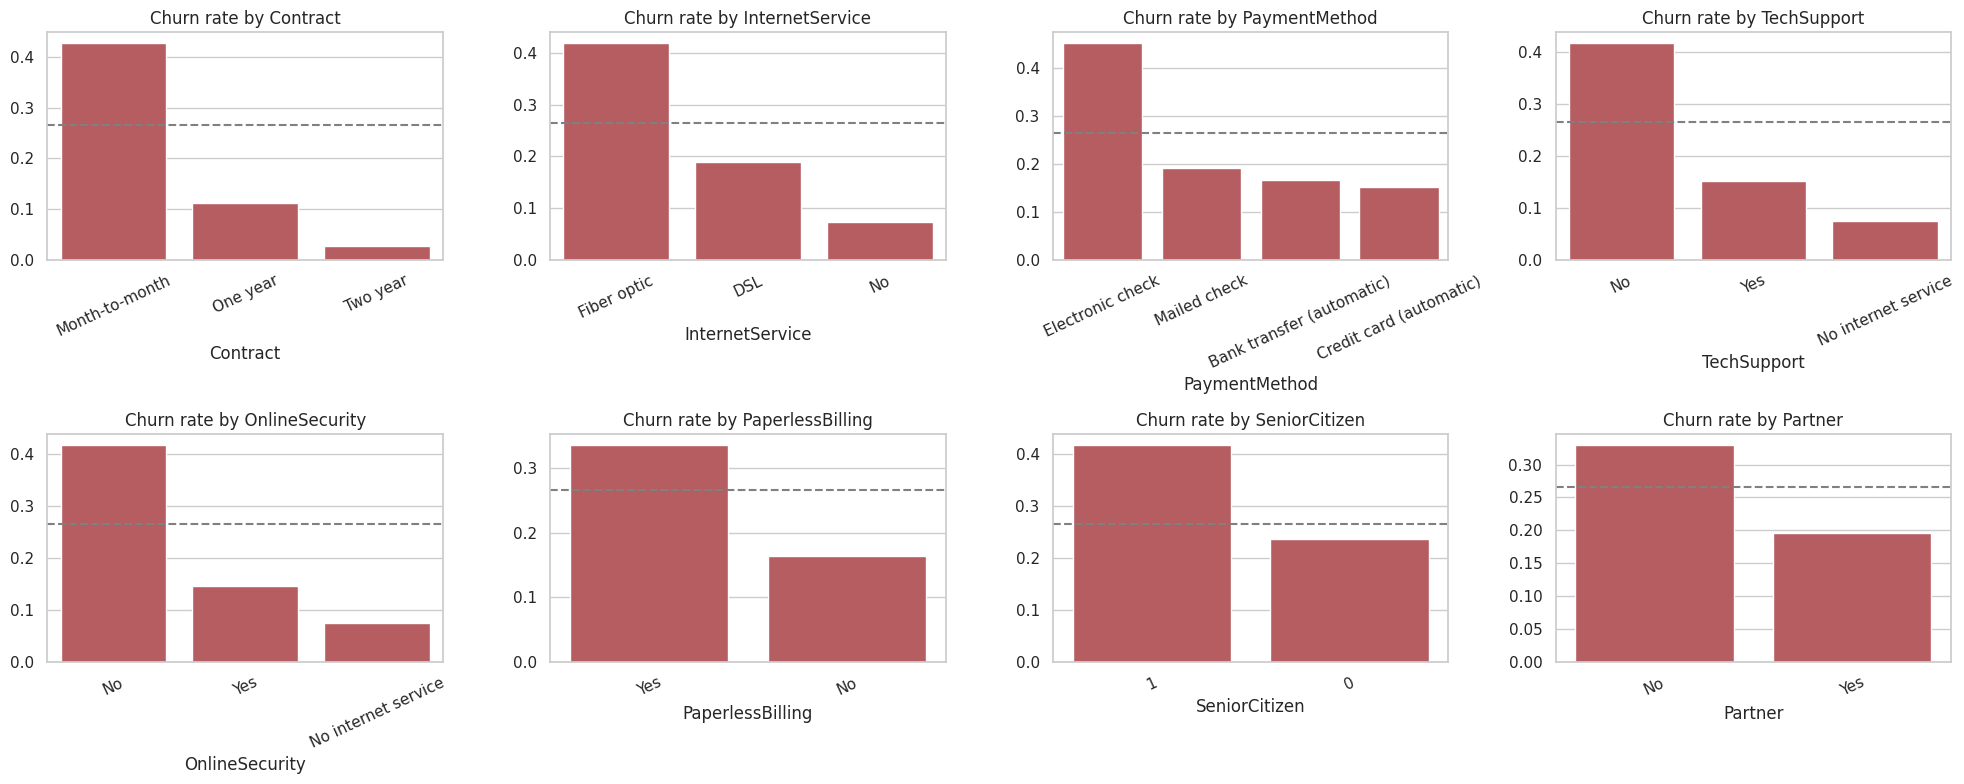

In [ ]:
# Categorical features vs churn
cols = ["Contract", "InternetService", "PaymentMethod", "TechSupport",
        "OnlineSecurity", "PaperlessBilling", "SeniorCitizen", "Partner"]
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, c in zip(axes.ravel(), cols):
    rate = df.groupby(c)["Churn"].mean().sort_values(ascending=False)
    sns.barplot(x=rate.index.astype(str), y=rate.values, ax=ax, color="#C44E52")
    ax.axhline(df["Churn"].mean(), ls="--", color="grey")
    ax.set_title(f"Churn rate by {c}"); ax.tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()

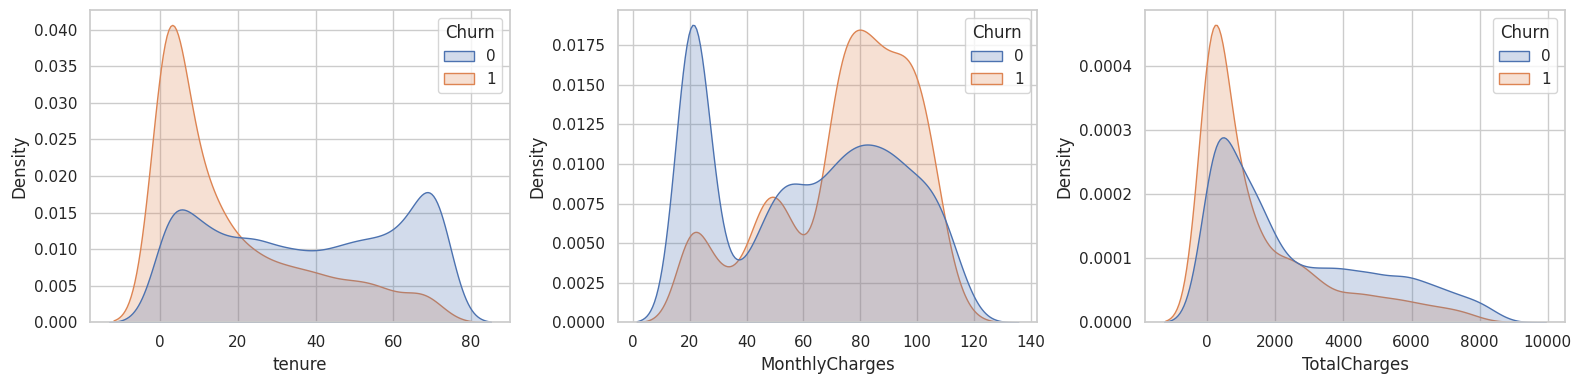

In [ ]:
# Numeric features vs churn
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, c in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.kdeplot(data=df, x=c, hue="Churn", fill=True, common_norm=False, ax=ax)
plt.tight_layout(); plt.show()

In [ ]:
# Tenure bucket
b = pd.cut(df["tenure"], [-1, 6, 12, 24, 48, 72], labels=["0-6", "7-12", "13-24", "25-48", "49-72"])
print(df.groupby(b)["Churn"].mean().map("{:.1%}".format))

tenure
0-6      52.9%
7-12     35.9%
13-24    28.7%
25-48    20.4%
49-72     9.5%
Name: Churn, dtype: object


**Step 5: Feature engineering**

Create three new features: number of add-on services, average monthly spend, and a flag for new customers (tenure ≤ 6 months). These capture customer behavior that the raw columns don't show directly.

In [ ]:
service_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                "TechSupport", "StreamingTV", "StreamingMovies"]

def add_features(data):
    data = data.copy()
    data["num_services"] = (data[service_cols] == "Yes").sum(axis=1)
    data["avg_monthly_spend"] = data["TotalCharges"] / data["tenure"].replace(0, 1)
    data["is_new_customer"] = (data["tenure"] <= 6).astype(int)
    return data

df_fe = add_features(df)

**Step 6: Split and preprocessing**

 Split the data 80/20 with stratification so both sets keep the same churn ratio. Scale numeric columns and one-hot encode categorical ones inside a Pipeline to prevent data leakage.

In [ ]:
X = df_fe.drop(columns="Churn")
y = df_fe["Churn"]

num_features = ["tenure", "MonthlyCharges", "TotalCharges", "num_services", "avg_monthly_spend"]
cat_features = [c for c in X.columns if c not in num_features]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), cat_features),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

**Step 7: Train the Models**

Train Logistic Regression, Random Forest, and XGBoost, using class weights to handle the imbalance between churners and non-churners. Also run 5-fold cross-validation to get a more reliable performance estimate.

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=400, min_samples_leaf=5,
                                            class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8,
                             colsample_bytree=0.8, scale_pos_weight=pos_weight,
                             eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
pipes, probas, rows = {}, {}, []

for name, model in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc").mean()
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    pipes[name], probas[name] = pipe, proba
    rows.append({"Model": name, "Accuracy": accuracy_score(y_test, pred),
                 "Recall": recall_score(y_test, pred), "Precision": precision_score(y_test, pred),
                 "ROC-AUC": roc_auc_score(y_test, proba), "CV ROC-AUC": cv_auc})

results = pd.DataFrame(rows).set_index("Model").round(3)
results

,Accuracy,Recall,Precision,ROC-AUC,CV ROC-AUC
Model,,,,,
Logistic Regression,0.742,0.799,0.509,0.846,0.848
Random Forest,0.771,0.727,0.553,0.840,0.844
XGBoost,0.749,0.786,0.518,0.845,0.846


**Step 8: ROC curve and confusion matrix**

Compare the models using accuracy, recall, precision, and ROC-AUC, along with ROC curves and confusion matrices. Recall and AUC matter most here because accuracy alone is misleading on imbalanced data.

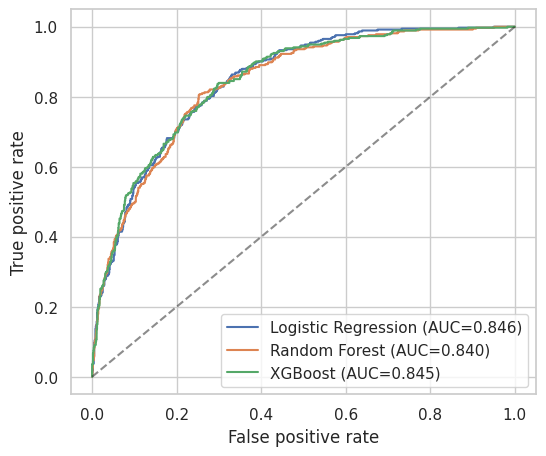

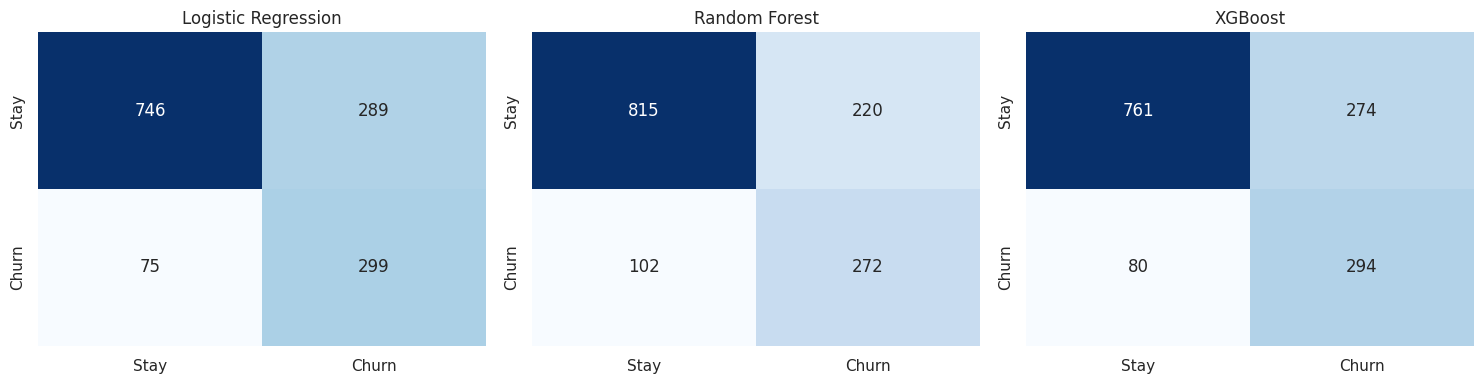

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, p in probas.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, p):.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.legend(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, p) in zip(axes, probas.items()):
    sns.heatmap(confusion_matrix(y_test, (p >= 0.5).astype(int)), annot=True, fmt="d",
                cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Stay", "Churn"], yticklabels=["Stay", "Churn"])
    ax.set_title(name)
plt.tight_layout(); plt.show()

**Step 9: Threshold tuning**

Default 0.5 cutoff arbitrary. Churner-a miss panradhu, wasted offer-a vida costly. So 75% recall varum threshold-a kandu pidikkrom.

In [ ]:
best_name = results["ROC-AUC"].idxmax()
best_proba = probas[best_name]
prec, rec, thr = precision_recall_curve(y_test, best_proba)

idx = np.where(rec[:-1] >= 0.75)[0][-1]
tuned_t = thr[idx]
tuned_pred = (best_proba >= tuned_t).astype(int)

print(best_name, f"| threshold={tuned_t:.2f}")
print(f"Recall {recall_score(y_test, tuned_pred):.3f} | "
      f"Precision {precision_score(y_test, tuned_pred):.3f} | "
      f"Accuracy {accuracy_score(y_test, tuned_pred):.3f}")

Logistic Regression | threshold=0.56
Recall 0.751 | Precision 0.540 | Accuracy 0.764


**Step 10: Hyperparameter tuning (optional, 1-3 min)**

 Use RandomizedSearchCV to test 25 different XGBoost settings and pick the best by cross-validated ROC-AUC. The gain is small (AUC 0.846 → 0.849), showing the models are already near their limit on this data.

In [ ]:
xgb_pipe = Pipeline([("prep", preprocess),
                     ("model", XGBClassifier(scale_pos_weight=pos_weight, eval_metric="logloss",
                                             random_state=RANDOM_STATE, n_jobs=-1))])
params = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [2, 3, 4, 5],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__min_child_weight": [1, 3, 5, 10],
    "model__reg_lambda": [1, 5, 10],
}
search = RandomizedSearchCV(xgb_pipe, params, n_iter=25, scoring="roc_auc",
                            cv=cv, random_state=RANDOM_STATE, n_jobs=-1)
search.fit(X_train, y_train)

tuned = search.best_estimator_.predict_proba(X_test)[:, 1]
print("CV AUC:", round(search.best_score_, 4), "| Test AUC:", round(roc_auc_score(y_test, tuned), 3))

CV AUC: 0.8501 | Test AUC: 0.849


**Step 11: Feature Importance**

Identify which features drive churn using XGBoost importance and Logistic Regression coefficients. The top drivers are month-to-month contracts, missing online security or tech support, fiber optic service, and short tenure.


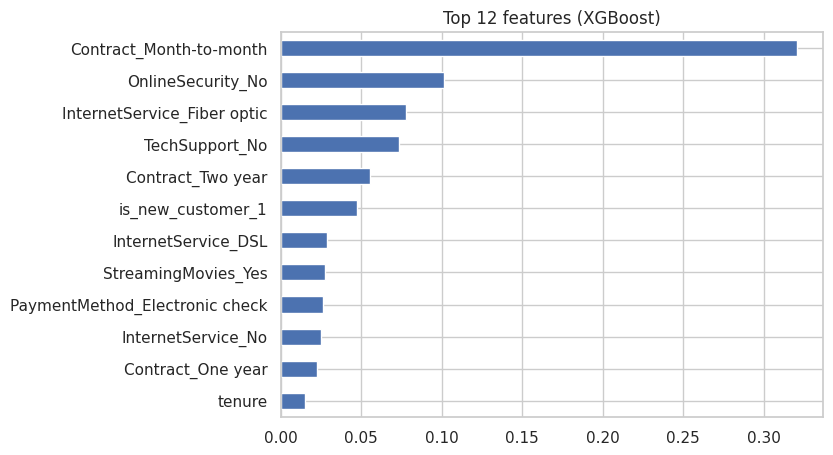

In [ ]:
names = [n.split("__", 1)[1] for n in pipes["XGBoost"].named_steps["prep"].get_feature_names_out()]

imp = pd.Series(pipes["XGBoost"].named_steps["model"].feature_importances_,
                index=names).sort_values(ascending=False).head(12)
imp[::-1].plot.barh(figsize=(7, 5), color="#4C72B0", title="Top 12 features (XGBoost)")
plt.show()

**Step 12: Save Model and Predict**

 Save the trained pipeline and tuned threshold with joblib so it can be reused without retraining. Then load it to score a new customer and flag high-risk ones for retention offers.

In [ ]:
joblib.dump({"model": pipes[best_name], "threshold": float(tuned_t), "model_name": best_name},
            "churn_model.joblib")

try:
    from google.colab import files
    files.download("churn_model.joblib")
except ImportError:
    pass

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Step 13: Conclusions and Recommendations**

Summarize the results (ROC-AUC ≈ 0.85, ~75% recall at the tuned threshold) and the customer segments most likely to churn. Recommend actions such as pushing annual contracts, bundling tech support, and targeting the first six months

In [ ]:
new_customer = pd.DataFrame([{
    "gender": "Female", "SeniorCitizen": 0, "Partner": "No", "Dependents": "No",
    "tenure": 3, "PhoneService": "Yes", "MultipleLines": "No",
    "InternetService": "Fiber optic", "OnlineSecurity": "No", "OnlineBackup": "No",
    "DeviceProtection": "No", "TechSupport": "No", "StreamingTV": "Yes", "StreamingMovies": "Yes",
    "Contract": "Month-to-month", "PaperlessBilling": "Yes", "PaymentMethod": "Electronic check",
    "MonthlyCharges": 95.5, "TotalCharges": 290.0,
}])

saved = joblib.load("churn_model.joblib")
prob = saved["model"].predict_proba(add_features(new_customer))[0, 1]
print(f"Churn probability: {prob:.1%}")
print("HIGH RISK: Offer a retention deal " if prob >= saved["threshold"] else "Low risk")

Churn probability: 92.9%
HIGH RISK: Offer a retention deal 
